# AOD DDS Lab Control Notebook — Plan B Concise

**Purpose:** Control and test the Spectrum M4i.6622-x8 DDS on the lab computer, first with an oscilloscope and later with the AOD.

This **Plan B** version keeps the same experimental workflow and explanations as the refined notebook, while reducing repeated code with a few small reusable helper functions.

### Hardware
- AWG / DDS card: **Spectrum M4i.6622-x8**
- Serial number: **23161**
- Device handle: **`/dev/spcm0`**
- Output channel: **CH0**
- Oscilloscope: **LeCroy 9354AM**
- Scope channel used here: **C2**
- AOD: **AA Opto-Electronic DTSX-400-800**

### Reference
Spectrum `spcm` DDS examples:  
`https://github.com/SpectrumInstrumentation/spcm/tree/master/src/examples/03_dds`

Main references used here:
- `01_dds_single_static_carrier.py`
- `02_dds_multiple_static_carriers.py`
- `03_dds_ramp_single_carrier.py`
- `05_dds_timed_frequency_changes.py`
- `06_dds_time_continuous_changes.py`
- `99_dds_graphical_user_interface.py`

### Recommended test order
1. Install / environment check
2. Card connection check
3. DDS initialization check
4. CH0 → Scope: single tone
5. Verify frequency and amplitude on scope
6. CH0 → Scope: multiple tones
7. LeCroy waveform → Python FFT
8. Frequency-movement tests
9. Only after electrical verification: amplifier / AOD test

**Important:** Run cells manually from top to bottom. Do not connect the RF amplifier or AOD until the direct AWG → Scope test is understood.


### Install `spcm`

Run this first in the Jupyter kernel used for the experiment. `%pip` installs the package into the current notebook environment.


In [1]:
%pip install spcm

Note: you may need to restart the kernel to use updated packages.


## 1. Environment Check

This cell does not control the hardware. It only checks the Python environment and imports `spcm` together with the packages used for LeCroy waveform acquisition, FFT analysis, plotting, and animation.


In [2]:
import sys, math, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

import spcm
from spcm import units
from Equipments import LeCroyScope

print("Python:", sys.version.split()[0])
print("spcm imported successfully")


Python: 3.13.12
spcm imported successfully


## 2. Main Lab Configuration

**Most hardware settings should be changed here.**

For the present setup, the values below should normally stay unchanged.


In [3]:
DEVICE = "/dev/spcm0"
EXPECTED_MODEL = "M4i.6622-x8"
EXPECTED_SERIAL = 23161

CHANNEL = spcm.CHANNEL0
LOAD = 50 * units.ohm

LECROY_ADDRESS = "GPIB0::3::INSTR"
SCOPE_CHANNEL = "C2"

print("Device:", DEVICE)
print("Expected model:", EXPECTED_MODEL)
print("Expected serial:", EXPECTED_SERIAL)


Device: /dev/spcm0
Expected model: M4i.6622-x8
Expected serial: 23161


### Reusable Setup Helpers

The original notebook repeats the same Spectrum card / channel / DDS initialization in several test cells.

Plan B keeps the same hardware behavior but moves only that repeated setup into small helper functions. The actual DDS commands for each experiment remain visible in the corresponding test cells.


In [4]:
def open_dds(channel_range=None):
    card = spcm.Card(DEVICE).open()
    try:
        if card.product_name() != EXPECTED_MODEL or card.sn() != EXPECTED_SERIAL:
            raise RuntimeError(
                f"Unexpected card: {card.product_name()}, serial {card.sn()}"
            )

        card.card_mode(spcm.SPC_REP_STD_DDS)
        channels = spcm.Channels(card, card_enable=CHANNEL)
        channels[0].enable(True)
        channels[0].output_load(LOAD)

        if channel_range is not None:
            channels[0].amp(channel_range)

        card.write_setup()  # required for DDS clock signals
        dds = spcm.DDS(card, channels=channels)
        dds.reset()
        return card, dds

    except Exception:
        card.close()
        raise


def start_output(card):
    card.start(
        spcm.M2CMD_CARD_ENABLETRIGGER,
        spcm.M2CMD_CARD_FORCETRIGGER,
    )


def stop_output(card):
    try:
        card.stop()
    finally:
        card.close()


def open_lecroy():
    scope = LeCroyScope.LeCroyScope(LECROY_ADDRESS, timeout=20000)
    scope.setup_transfer()
    return scope


def read_lecroy(scope, channel=SCOPE_CHANNEL):
    t, v, info = scope.read_waveform(channel)
    return np.asarray(t, float), np.asarray(v, float), info


## 3. Card Connection Check

Opens the card, reads its identity, verifies the model and serial number, then closes it.

No DDS configuration and no RF output are used here.


In [5]:
with spcm.Card(DEVICE) as card:
    model, serial = card.product_name(), card.sn()
    print("Connected successfully")
    print("Model:", model)
    print("Serial:", serial)

    if model != EXPECTED_MODEL or serial != EXPECTED_SERIAL:
        raise RuntimeError(f"Unexpected card: {model}, serial {serial}")

print("Connection check passed")


Connected successfully
Model: M4i.6622-x8
Serial: 23161
Connection check passed


## 4. DDS Initialization Check

Verifies that the M4i.6622-x8 can enter DDS mode and create a DDS object.

This cell still does **not** start RF output.


In [6]:
card, dds = open_dds()

print("DDS initialized successfully")
print("Available DDS cores:", len(dds))

stop_output(card)
print("DDS initialization check passed")


DDS initialized successfully
Available DDS cores: 23
DDS initialization check passed


## 5. Single-Tone Scope Test — Settings

Use this section for the first physical test:

`M4i CH0 → 50 Ω coax → Scope`

The values below are **scope-test values**, not the final AOD operating settings.

Before running the output cell:
- connect **CH0** to the LeCroy;
- press **Coupling** on the LeCroy;
- select the corresponding channel, currently **C2**;
- set the input impedance to **50 Ω**;
- do not connect the RF amplifier yet.


In [7]:
CHANNEL_RANGE = 0.5 * units.V

TEST_FREQUENCY = 10 * units.MHz
TEST_AMPLITUDE = 100 * units.mV
TEST_PHASE = 0 * units.degrees

print("Frequency:", TEST_FREQUENCY)
print("DDS amplitude:", TEST_AMPLITUDE)
print("Phase:", TEST_PHASE)


Frequency: 10 MHz
DDS amplitude: 100 mV
Phase: 0 deg


## 6. Single-Tone RF Output

This cell starts one DDS carrier on CH0.

In Plan B, RF ON/OFF is controlled explicitly instead of waiting for `Enter`. The card remains active after this cell so that the LeCroy can measure it. Run the separate **Stop Single-Tone Output** cell when the measurement is finished.


In [10]:
card, dds = open_dds(CHANNEL_RANGE)

dds[0].freq(TEST_FREQUENCY)
dds[0].amp(TEST_AMPLITUDE)
dds[0].phase(TEST_PHASE)

print("Programmed frequency:", dds[0].get_freq(return_unit=units.MHz))
print("Programmed amplitude:", dds[0].get_amp(return_unit=units.mV))
print("Programmed phase:", dds[0].get_phase(return_unit=units.degrees))

dds.exec_at_trg()
dds.write_to_card()
start_output(card)

print("RF output ON")


Programmed frequency: 9.999999892897904 MHz
Programmed amplitude: 99.9938962981048 mV
Programmed phase: 0.0 deg
RF output ON


### Stop Single-Tone Output

Run this cell after the single-tone scope measurement is complete. It stops the RF output and closes the active Spectrum card handle.


In [12]:
stop_output(card)
print("RF output OFF")


RF output OFF


## 7. Scope Measurement / RF Power Estimate

After measuring the sine wave on the scope, enter the measured **Vpp in volts** below.

For a sine wave into 50 Ω:

\[
P = \frac{V_{pp}^2}{8R}
\]

This is useful for checking the electrical signal before adding the RF amplifier.


In [11]:
MEASURED_VPP_V = 0.192   # replace with the current LeCroy measurement
R_OHM = 50

if MEASURED_VPP_V is None:
    print("Enter MEASURED_VPP_V after taking a scope measurement.")
else:
    power_W = MEASURED_VPP_V**2 / (8 * R_OHM)
    power_dBm = 10 * math.log10(power_W / 1e-3)

    print(f"Measured Vpp: {MEASURED_VPP_V:.6g} V")
    print(f"Estimated power into 50 Ω: {power_W:.6g} W")
    print(f"Estimated power: {power_W*1e3:.6g} mW")
    print(f"Estimated power: {power_dBm:.3f} dBm")


Measured Vpp: 0.192 V
Estimated power into 50 Ω: 9.216e-05 W
Estimated power: 0.09216 mW
Estimated power: -10.355 dBm


## 8. Multi-Tone Scope Test — Settings

Only use this after the single-tone test works.

Start with **2 tones**, then increase gradually.

The total DDS amplitude budget is divided equally among the tones.


In [13]:
MULTI_FREQUENCIES = [100 * units.MHz, 110 * units.MHz]
MULTI_TOTAL_AMPLITUDE = 10 * units.percent
MULTI_PHASE = 0 * units.degrees

print("Number of tones:", len(MULTI_FREQUENCIES))
print("Frequencies:", MULTI_FREQUENCIES)
print("Total DDS amplitude budget:", MULTI_TOTAL_AMPLITUDE)


Number of tones: 2
Frequencies: [<Quantity(100, 'megahertz')>, <Quantity(110, 'megahertz')>]
Total DDS amplitude budget: 10 %


## 9. Multi-Tone RF Output

This cell assigns one DDS core to each frequency.

Use the LeCroy waveform acquisition and Python FFT below to verify that all programmed tones are present.

As with the single-tone test, Plan B keeps RF active until the separate stop cell is run.


In [50]:
card, dds = open_dds(CHANNEL_RANGE)

if len(MULTI_FREQUENCIES) > len(dds):
    raise ValueError(
        f"Requested {len(MULTI_FREQUENCIES)} tones, "
        f"but only {len(dds)} DDS cores are available."
    )

amp_each = MULTI_TOTAL_AMPLITUDE / len(MULTI_FREQUENCIES)

for i, frequency in enumerate(MULTI_FREQUENCIES):
    dds[i].freq(frequency)
    dds[i].amp(amp_each)
    dds[i].phase(MULTI_PHASE)
    print(
        f"Core {i}: "
        f"{dds[i].get_freq(return_unit=units.MHz)}, "
        f"{dds[i].get_amp(return_unit=units.percent)}"
    )

dds.exec_at_trg()
dds.write_to_card()
start_output(card)

print("Multi-tone RF output ON")


Core 0: 100.00000009313226 MHz, 0.0499893185216834 %
Core 1: 109.99999998603016 MHz, 0.0499893185216834 %
Multi-tone RF output ON


### Stop Multi-Tone Output

Run this cell after the multi-tone scope / FFT measurement is complete.


In [54]:
stop_output(card)
print("RF output OFF")


RF output OFF


### LeCroy Waveform Acquisition and Python FFT

The analysis flow is:

`RF signal → LeCroy C2 → waveform (t, v) → Python FFT → frequency-domain spectrum`

Before acquisition, manually set the LeCroy input:

**Coupling → C2 → 50 Ω**

The FFT uses the **time axis returned by the LeCroy** to determine the sample interval and sample rate. No sampling rate is hard-coded.

Processing:
1. calculate \(dt\) from `t`;
2. remove the waveform DC offset;
3. apply a Hann window to reduce spectral leakage;
4. use a one-sided real FFT;
5. correct the amplitude for the Hann-window coherent gain;
6. plot frequency in MHz;
7. identify and label the strongest spectral peaks.

For the present multi-tone test, the expected peaks are near the programmed RF frequencies.


*IDN -> LECROY,9354AM,935403739,08.2.1

Points: 1001
Time range: -1.2000000000000002e-07 to 8.799999717180685e-07 S


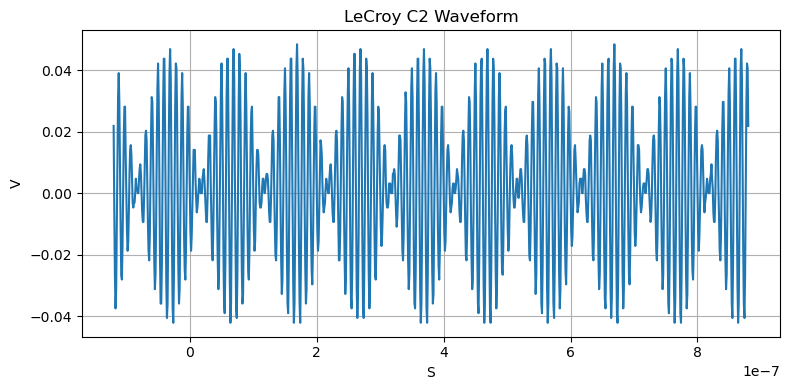

In [51]:
scope = open_lecroy()
try:
    t, v, info = read_lecroy(scope)
finally:
    scope.close()

print("Points:", len(t))
print("Time range:", t[0], "to", t[-1], info["horizontal_unit"] or "s")

plt.figure(figsize=(8, 4))
plt.plot(t, v)
plt.xlabel(info["horizontal_unit"] or "s")
plt.ylabel(info["vertical_unit"] or "V")
plt.title(f"LeCroy {SCOPE_CHANNEL} Waveform")
plt.grid(True)
plt.tight_layout()
plt.show()


In [52]:
def compute_fft(t, v, window="hann"):
    t, v = np.asarray(t, float), np.asarray(v, float)

    if len(t) != len(v) or len(t) < 2:
        raise ValueError("t and v must have the same length and contain at least two points.")

    dt_values = np.diff(t)
    dt = np.median(dt_values)
    if dt <= 0:
        raise ValueError("Time axis must be increasing.")

    if np.std(dt_values) / abs(dt) > 1e-3:
        print("Warning: time spacing is not perfectly uniform.")

    n = len(v)
    signal = v - np.mean(v)
    w = np.hanning(n) if window == "hann" else np.ones(n)

    freq = np.fft.rfftfreq(n, dt)
    amp = 2 * np.abs(np.fft.rfft(signal * w)) / (n * np.mean(w))
    amp[0] *= 0.5
    if n % 2 == 0:
        amp[-1] *= 0.5

    meta = {
        "points": n,
        "dt_s": dt,
        "sample_rate_Hz": 1 / dt,
        "duration_s": t[-1] - t[0],
        "frequency_resolution_Hz": 1 / (n * dt),
        "window": window,
    }
    return freq, amp, meta


def plot_fft(t, v, fmin_MHz=None, fmax_MHz=None, n_peaks=5, prominence_fraction=0.05):
    freq, amp, meta = compute_fft(t, v)
    mask = np.ones(len(freq), dtype=bool)

    if fmin_MHz is not None:
        mask &= freq >= fmin_MHz * 1e6
    if fmax_MHz is not None:
        mask &= freq <= fmax_MHz * 1e6

    f, a = freq[mask], amp[mask]
    if not len(f):
        raise ValueError("Selected frequency range contains no FFT points.")

    peaks, _ = find_peaks(a, prominence=prominence_fraction * np.max(a))
    peaks = peaks[np.argsort(a[peaks])[-n_peaks:]] if len(peaks) else peaks
    peaks = peaks[np.argsort(f[peaks])]

    plt.figure(figsize=(9, 5))
    plt.plot(f / 1e6, a)

    peak_data = []
    for i in peaks:
        f_MHz, vpk = f[i] / 1e6, a[i]
        p_W = (vpk / np.sqrt(2))**2 / 50
        peak_data.append((f_MHz, vpk, 10 * np.log10(p_W / 1e-3) if p_W else -np.inf))
        # plt.plot(f_MHz, vpk, "o")
        # plt.annotate(f"{f_MHz:.3f} MHz", (f_MHz, vpk), xytext=(0, 8),
        #              textcoords="offset points", ha="center")

    plt.xlabel("Frequency [MHz]")
    plt.ylabel("Amplitude [Vpk]")
    plt.title("Measured RF Spectrum")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Points: {meta['points']}")
    print(f"Sample rate: {meta['sample_rate_Hz']/1e9:.6g} GSa/s")
    print(f"Record duration: {meta['duration_s']:.6g} s")
    print(f"FFT frequency resolution: {meta['frequency_resolution_Hz']/1e6:.6g} MHz")

    for f_MHz, vpk, dBm in peak_data:
        print(f"{f_MHz:.6f} MHz | {vpk:.6g} Vpk | {dBm:.3f} dBm (50 Ω estimate)")

    return freq, amp, meta, peak_data


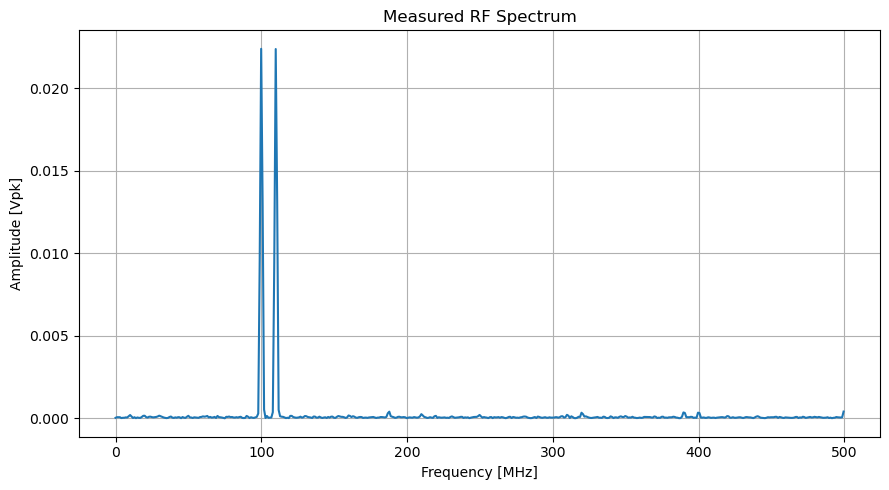

Points: 1001
Sample rate: 1 GSa/s
Record duration: 1e-06 s
FFT frequency resolution: 0.999001 MHz
99.900103 MHz | 0.022391 Vpk | -22.999 dBm (50 Ω estimate)
109.890113 MHz | 0.0223765 Vpk | -23.004 dBm (50 Ω estimate)


In [53]:
FFT_FMIN_MHZ = 0
FFT_FMAX_MHZ = 5e8

freq_Hz, amplitude_Vpk, fft_meta, fft_peaks = plot_fft(
    t, v,
    fmin_MHz=FFT_FMIN_MHZ,
    fmax_MHz=FFT_FMAX_MHZ,
)


In [25]:
# Optional: inspect the full one-sided spectrum for harmonics or spurs.
# plot_fft(t, v, fmin_MHz=0, fmax_MHz=None, n_peaks=10, prominence_fraction=0.02)


## 10. Frequency Movement Tests

These tests verify that the DDS carrier can move in frequency and that the movement can be observed reproducibly with the LeCroy + Python FFT pipeline.

Three levels are included:

1. **Live frequency jump + LeCroy acquisition**  
   Keep RF output running, update the active DDS frequency with `exec_now()`, acquire a LeCroy waveform at each setpoint, and measure the FFT peak.

2. **Timed frequency steps**  
   Queue several frequency changes and let the DDS internal timer apply them automatically.

3. **Linear frequency ramp**  
   Use the DDS `frequency_slope()` functionality to sweep continuously from one frequency to another.

> **IMPORTANT:** Before acquisition, on the LeCroy press **Coupling**, select the channel being used (currently C2), and set it to **50 Ω**.

The continuous FIFO / command-queue streaming example is intentionally not included yet; it is more complex than needed for the present Scope Test.


### 10.1 Test A — Live Frequency Jump + LeCroy FFT

This is the most useful frequency-movement test for the current setup.

The Spectrum card remains running while the frequency is changed:

`set new frequency → exec_now() → write_to_card()`

For every frequency:
1. update DDS core 0;
2. wait briefly for the signal / scope to settle;
3. acquire the waveform from LeCroy C2;
4. compute the FFT;
5. record the measured spectral peak.

This follows the live-update logic used in Spectrum's DDS GUI example.


In [46]:
FREQ_MOVE_POINTS_MHZ = [95, 99, 103, 107, 111]
FREQ_MOVE_AMPLITUDE = 100 * units.mV
FREQ_MOVE_PHASE = 0 * units.degrees
FREQ_MOVE_SETTLE_TIME_S = 3 # Can be changed for better visually observation on the scope

# NOTE: TIME/DIV setting of the oscilloscope should be appropriate (e.g. the waveform should contain enough peaks/periods for accurate FFT analysis; .1us for ~100MHz frequencies)

FFT_MOVE_FMIN_MHZ = 85
FFT_MOVE_FMAX_MHZ = 121

print("Frequency setpoints [MHz]:", FREQ_MOVE_POINTS_MHZ)
print("DDS amplitude:", FREQ_MOVE_AMPLITUDE)
print("Scope channel:", SCOPE_CHANNEL)


Frequency setpoints [MHz]: [95, 99, 103, 107, 111]
DDS amplitude: 100 mV
Scope channel: C2


In [38]:
def strongest_fft_peak(t, v, fmin_MHz, fmax_MHz):
    freq, amp, meta = compute_fft(t, v)
    mask = (freq >= fmin_MHz * 1e6) & (freq <= fmax_MHz * 1e6)

    if not np.any(mask):
        raise ValueError("Selected FFT range contains no data.")

    idx = np.where(mask)[0][np.argmax(amp[mask])]
    return freq, amp, meta, freq[idx] / 1e6, amp[idx]


In [45]:
frequency_movement_results = []

print(f"IMPORTANT: LeCroy → Coupling → {SCOPE_CHANNEL} → 50 Ω")

scope = open_lecroy()
card, dds = open_dds(CHANNEL_RANGE)

dds.trg_src(spcm.SPCM_DDS_TRG_SRC_NONE)
dds[0].amp(FREQ_MOVE_AMPLITUDE)
dds[0].freq(FREQ_MOVE_POINTS_MHZ[0] * units.MHz)
dds[0].phase(FREQ_MOVE_PHASE)
dds.exec_at_trg()
dds.write_to_card()

try:
    start_output(card)
    print("RF OUTPUT ON")

    for i, f_set in enumerate(FREQ_MOVE_POINTS_MHZ):
        if i:
            dds[0].freq(f_set * units.MHz)
            dds.exec_now()
            dds.write_to_card()

        time.sleep(FREQ_MOVE_SETTLE_TIME_S)
        t_i, v_i, _ = read_lecroy(scope)

        freq_i, amp_i, meta_i, peak_i, peak_amp_i = strongest_fft_peak(
            t_i, v_i, FFT_MOVE_FMIN_MHZ, FFT_MOVE_FMAX_MHZ
        )

        frequency_movement_results.append({
            "set_frequency_MHz": f_set,
            "measured_peak_MHz": peak_i,
            "peak_amplitude_Vpk": peak_amp_i,
            "frequency_Hz": freq_i,
            "amplitude_Vpk": amp_i,
            "fft_meta": meta_i,
            "t": t_i,
            "v": v_i,
        })

        print(f"Set {f_set:8.3f} MHz -> FFT peak {peak_i:10.6f} MHz")

finally:
    stop_output(card)
    scope.close()
    print("RF OUTPUT OFF")
    print("LeCroy connection closed")


IMPORTANT: LeCroy → Coupling → C2 → 50 Ω
*IDN -> LECROY,9354AM,935403739,08.2.1

RF OUTPUT ON
Set   95.000 MHz -> FFT peak  94.905098 MHz
Set   99.000 MHz -> FFT peak  98.901102 MHz
Set  103.000 MHz -> FFT peak 102.897106 MHz
Set  107.000 MHz -> FFT peak 106.893110 MHz
Set  111.000 MHz -> FFT peak 110.889114 MHz
RF OUTPUT OFF
LeCroy connection closed


### 10.2 Plot Frequency Movement in FFT Space

The next cells visualize the same measurement in several useful ways:

- overlaid FFT traces;
- programmed frequency vs measured FFT peak;
- a 2D frequency-movement map.

The 2D map is a static alternative to an animation and is usually easier to save as an experimental record.


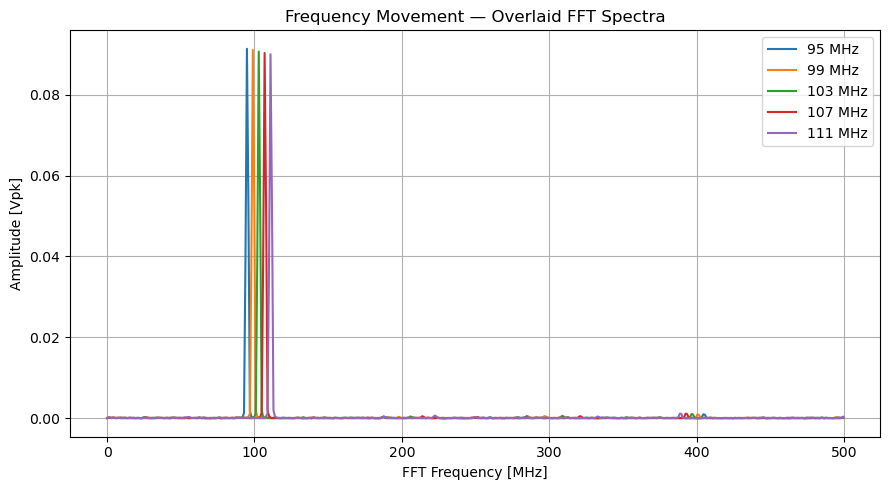

In [47]:
def movement_band(result):
    f = result["frequency_Hz"] / 1e6
    # mask = (f >= FFT_MOVE_FMIN_MHZ) & (f <= FFT_MOVE_FMAX_MHZ)
    mask = (f >= 0) & (f <= 5e8)

    return f[mask], result["amplitude_Vpk"][mask]


if not frequency_movement_results:
    print("Run Test A first.")
else:
    plt.figure(figsize=(9, 5))
    for r in frequency_movement_results:
        f, a = movement_band(r)
        plt.plot(f, a, label=f"{r['set_frequency_MHz']} MHz")

    plt.xlabel("FFT Frequency [MHz]")
    plt.ylabel("Amplitude [Vpk]")
    plt.title("Frequency Movement — Overlaid FFT Spectra")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


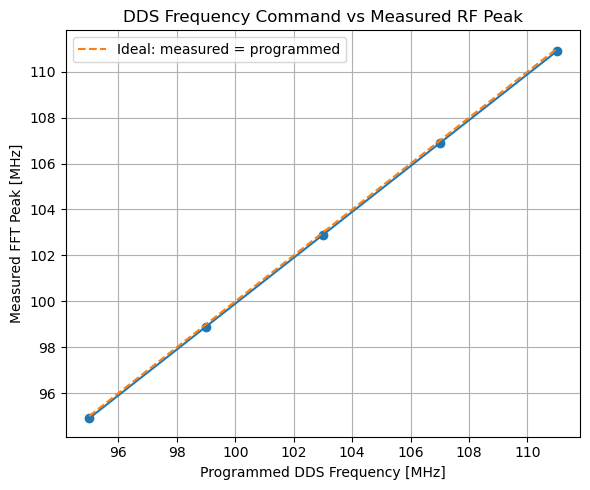

Frequency errors [kHz]:
    95.000 MHz ->  94.905098 MHz | error = -94.902 kHz
    99.000 MHz ->  98.901102 MHz | error = -98.898 kHz
   103.000 MHz -> 102.897106 MHz | error = -102.894 kHz
   107.000 MHz -> 106.893110 MHz | error = -106.890 kHz
   111.000 MHz -> 110.889114 MHz | error = -110.886 kHz


In [48]:
if not frequency_movement_results:
    print("Run Test A first.")
else:
    set_freqs = np.array([r["set_frequency_MHz"] for r in frequency_movement_results])
    measured_freqs = np.array([r["measured_peak_MHz"] for r in frequency_movement_results])

    plt.figure(figsize=(6, 5))
    plt.plot(set_freqs, measured_freqs, "o-")
    plt.plot([set_freqs.min(), set_freqs.max()],
             [set_freqs.min(), set_freqs.max()], "--",
             label="Ideal: measured = programmed")
    plt.xlabel("Programmed DDS Frequency [MHz]")
    plt.ylabel("Measured FFT Peak [MHz]")
    plt.title("DDS Frequency Command vs Measured RF Peak")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Frequency errors [kHz]:")
    for f_set, f_meas in zip(set_freqs, measured_freqs):
        print(f"  {f_set:8.3f} MHz -> {f_meas:10.6f} MHz"
              f" | error = {(f_meas-f_set)*1e3:+.3f} kHz")


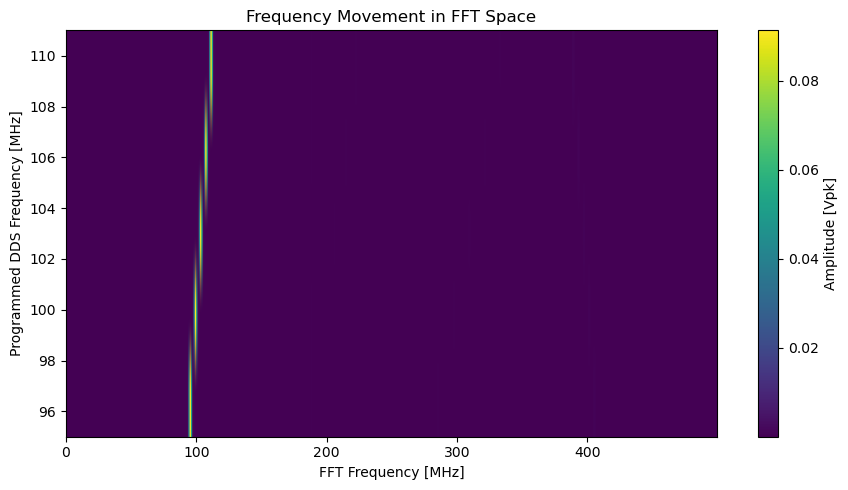

In [49]:
if not frequency_movement_results:
    print("Run Test A first.")
else:
    common_f, _ = movement_band(frequency_movement_results[0])
    matrix = np.array([
        np.interp(common_f, r["frequency_Hz"]/1e6, r["amplitude_Vpk"])
        for r in frequency_movement_results
    ])

    set_freqs = np.array([r["set_frequency_MHz"] for r in frequency_movement_results])

    plt.figure(figsize=(9, 5))
    plt.imshow(
        matrix,
        aspect="auto",
        origin="lower",
        extent=[common_f[0], common_f[-1], set_freqs[0], set_freqs[-1]],
    )
    plt.xlabel("FFT Frequency [MHz]")
    plt.ylabel("Programmed DDS Frequency [MHz]")
    plt.title("Frequency Movement in FFT Space")
    plt.colorbar(label="Amplitude [Vpk]")
    plt.tight_layout()
    plt.show()


### 10.3 Test B — DDS Timer-Triggered Frequency Steps

This follows Spectrum's `05_dds_timed_frequency_changes.py` pattern.

Several frequencies are queued before the card starts. The DDS internal timer then advances from one frequency to the next automatically.

This is useful for verifying movement that does not depend on Python issuing every update in real time.

The cell stops automatically after the complete sequence.


In [55]:
TIMED_FREQUENCIES_MHZ = [95, 103, 111]
TIMED_STEP_PERIOD_S = 2.0
TIMED_AMPLITUDE = 100 * units.mV

card, dds = open_dds(CHANNEL_RANGE)
dds.trg_src(spcm.SPCM_DDS_TRG_SRC_TIMER)
dds.trg_timer(TIMED_STEP_PERIOD_S * units.s)
dds[0].amp(TIMED_AMPLITUDE)

for f_MHz in TIMED_FREQUENCIES_MHZ:
    dds[0].freq(f_MHz * units.MHz)
    dds.exec_at_trg()

dds.write_to_card()

print("Timed sequence:", " -> ".join(f"{f} MHz" for f in TIMED_FREQUENCIES_MHZ))
print("Step period:", TIMED_STEP_PERIOD_S, "s")

try:
    start_output(card)
    print("TIMED FREQUENCY MOVEMENT ON")
    time.sleep(TIMED_STEP_PERIOD_S * len(TIMED_FREQUENCIES_MHZ))
finally:
    stop_output(card)
    print("RF OUTPUT OFF")


Timed sequence: 95 MHz -> 103 MHz -> 111 MHz
Step period: 2.0 s
TIMED FREQUENCY MOVEMENT ON
RF OUTPUT OFF


### 10.4 Test C — Linear Frequency Ramp

This follows the frequency-ramp logic in Spectrum's `03_dds_ramp_single_carrier.py`.

The sequence is:

1. output the start frequency;
2. after one timer period, enable a linear `frequency_slope`;
3. ramp for one timer period;
4. stop the slope and force the final frequency.

During the ramp, the RF spectral peak should move continuously rather than jump between discrete frequencies.


In [56]:
RAMP_START_MHZ, RAMP_STOP_MHZ = 95, 111
RAMP_TIME_S = 2.0
RAMP_FINAL_HOLD_S = 1.0
RAMP_AMPLITUDE = 100 * units.mV
RAMP_STEP_DIVIDER = 1000

slope = (
    (RAMP_STOP_MHZ - RAMP_START_MHZ)
    * units.MHz / (RAMP_TIME_S * units.s)
)

card, dds = open_dds(CHANNEL_RANGE)
dds.trg_src(spcm.SPCM_DDS_TRG_SRC_TIMER)
dds.trg_timer(RAMP_TIME_S * units.s)
dds.freq_ramp_stepsize(RAMP_STEP_DIVIDER)

dds[0].amp(RAMP_AMPLITUDE)
dds[0].freq(RAMP_START_MHZ * units.MHz)
dds.exec_at_trg()

dds[0].frequency_slope(slope)
dds.exec_at_trg()

dds[0].frequency_slope(0 * units.MHz / units.s)
dds[0].freq(RAMP_STOP_MHZ * units.MHz)
dds.exec_at_trg()

dds.write_to_card()

print(f"Ramp: {RAMP_START_MHZ} -> {RAMP_STOP_MHZ} MHz")
print("Ramp time:", RAMP_TIME_S, "s")
print("Frequency slope:", slope)

try:
    start_output(card)
    print("LINEAR FREQUENCY RAMP ON")
    time.sleep(2 * RAMP_TIME_S + RAMP_FINAL_HOLD_S)
finally:
    stop_output(card)
    print("RF OUTPUT OFF")


Ramp: 95 -> 111 MHz
Ramp time: 2.0 s
Frequency slope: 8.0 MHz/s
LINEAR FREQUENCY RAMP ON
RF OUTPUT OFF


### 10.5 What to Verify

For the present Scope Test, the useful checks are:

- **Test A:** FFT peak follows the programmed setpoint while the RF output remains running.
- **Overlay plot:** individual spectra move across frequency without unexpected large spurs.
- **Set vs measured plot:** measured peak frequency tracks the DDS command.
- **2D FFT map:** the spectral ridge moves with programmed frequency.
- **Test B:** timed DDS commands produce discrete automatic jumps.
- **Test C:** `frequency_slope()` produces continuous movement between the endpoints.

The more advanced DDS FIFO / command-queue streaming mode should be added only after these simpler movement modes are experimentally verified.


### 10.6 Animation of Frequency Movement

This animation uses the already acquired `frequency_movement_results` from **Test A**.

Each frame shows one measured FFT spectrum. The title indicates the programmed DDS frequency, and a marker highlights the strongest measured FFT peak.

This is only a visualization layer:
- it does **not** control the AWG;
- it does **not** re-acquire the waveform;
- it only reuses the measured spectra already stored in memory.


In [57]:
ANIMATION_INTERVAL_MS = 1000
ANIMATION_REPEAT = True

print("Animation frequency window:", FFT_MOVE_FMIN_MHZ, "to", FFT_MOVE_FMAX_MHZ, "MHz")
print("Frame interval [ms]:", ANIMATION_INTERVAL_MS)


Animation frequency window: 85 to 121 MHz
Frame interval [ms]: 1000


In [58]:
if not frequency_movement_results:
    print("Run Test A first to generate frequency_movement_results.")
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    ymax = max(np.max(movement_band(r)[1]) for r in frequency_movement_results)

    line, = ax.plot([], [], lw=2)
    marker, = ax.plot([], [], "o")
    text = ax.text(0.02, 0.95, "", transform=ax.transAxes, va="top")

    ax.set_xlim(FFT_MOVE_FMIN_MHZ, FFT_MOVE_FMAX_MHZ)
    ax.set_ylim(0, 1.1 * ymax)
    ax.set_xlabel("FFT Frequency [MHz]")
    ax.set_ylabel("Amplitude [Vpk]")
    ax.grid(True)

    def update(i):
        r = frequency_movement_results[i]
        f, a = movement_band(r)

        line.set_data(f, a)
        marker.set_data([r["measured_peak_MHz"]], [r["peak_amplitude_Vpk"]])
        text.set_text(
            f"Set DDS: {r['set_frequency_MHz']:.3f} MHz\n"
            f"Measured peak: {r['measured_peak_MHz']:.6f} MHz"
        )
        ax.set_title(f"Frequency Movement Animation — Frame {i+1}/{len(frequency_movement_results)}")
        return line, marker, text

    ani = FuncAnimation(
        fig,
        update,
        frames=len(frequency_movement_results),
        interval=ANIMATION_INTERVAL_MS,
        repeat=ANIMATION_REPEAT,
    )

    plt.close(fig)
    display(HTML(ani.to_jshtml()))


### 10.7 Optional Use

The animation is mainly for quick visual confirmation or presentation.

For lab records, the most important static outputs are still:
- overlaid FFT spectra;
- programmed vs measured frequency plot;
- 2D FFT movement map.


## 11. AOD Specifications / Future AOD Test Settings

AOD: **AA Opto-Electronic DTSX-400-800**

Known values:
- optical wavelength range: approximately 780–820 nm
- active aperture: approximately 7.5 × 7.5 mm²
- RF input impedance: 50 Ω
- RF frequency span / range: approximately 36 MHz
- maximum RF power at the AOD input: < 2 W

The exact **center frequency / usable RF endpoints for this physical AOD** should be taken from its calibration sheet or unit documentation.

Do not interpret the AWG DDS amplitude setting as the RF power delivered to the AOD. The later chain is:

`M4i CH0 → RF amplifier → cable / loss → AOD`

The RF power limit applies at the **AOD RF input**.


In [ ]:
AOD_MODEL = "DTSX-400-800"
AOD_RF_SPAN = 36 * units.MHz
AOD_IMPEDANCE = 50 * units.ohm
AOD_MAX_RF_POWER = 2 * units.W

# Fill these from the calibration sheet of the actual AOD:
AOD_CENTER_FREQUENCY = None
AOD_RF_MIN = None
AOD_RF_MAX = None

print("AOD model:", AOD_MODEL)
print("RF span:", AOD_RF_SPAN)
print("Maximum RF power at AOD input:", AOD_MAX_RF_POWER)

if AOD_CENTER_FREQUENCY is None:
    print("AOD center frequency: NOT YET ENTERED")


## 12. AOD Frequency Readiness Check

Run this before using the actual AOD frequency settings.

It intentionally refuses to proceed until the unit-specific RF frequency information has been entered.


In [ ]:
if AOD_CENTER_FREQUENCY is None:
    raise ValueError(
        "AOD center frequency is not set. "
        "Enter the value from the calibration sheet before an AOD RF test."
    )

print("AOD center frequency:", AOD_CENTER_FREQUENCY)

if AOD_RF_MIN is not None and AOD_RF_MAX is not None:
    print("AOD RF interval:", AOD_RF_MIN, "to", AOD_RF_MAX)

print("AOD frequency information is ready.")


## 13. Emergency / Manual Stop

If an output cell is interrupted and you are unsure whether the card is still running, run this cell.

This does not replace physically disconnecting or disabling the RF chain when required.


In [ ]:
with spcm.Card(DEVICE) as card:
    card.stop()

print("Stop command sent to M4i.6622-x8")


## 14. Quick Troubleshooting

### `import spcm` fails
Run the `%pip install spcm` cell at the top and confirm the package is installed in the same Python / Jupyter environment.

### Card cannot open
Check:
- Spectrum driver
- `/dev/spcm0`
- card permissions
- Spectrum Control Center

### Model / serial check fails
Stop and verify which physical card is being opened.

### DDS initialization fails
Check:
- DDS firmware / feature
- driver and `spcm` version
- card mode and channel configuration

### Scope shows no signal
Check:
- correct physical connector: **CH0**
- 50 Ω coax
- scope channel enabled
- on the LeCroy: **Coupling → selected channel (currently C2) → 50 Ω**
- output cell actually reached `RF output ON`
- frequency / time-base settings on the scope

### Frequency is correct but amplitude is unexpected
Check:
- LeCroy input is actually set to 50 Ω
- channel range
- DDS amplitude
- cable / adapters
- whether the scope reports Vpp, Vrms, or another quantity

### Before connecting the AOD
Confirm:
- unit-specific AOD RF frequency range
- RF amplifier gain
- output power after the amplifier
- cable / coupler loss
- final RF power delivered to the AOD is below its allowed limit
